# **Preprocessing**

In [ ]:
!pip install stopwordsiso
import pandas as pd
import numpy as np
import re
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text
from sklearn.metrics import accuracy_score, classification_report
from scipy.sparse import hstack, csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.decomposition import TruncatedSVD
import plotly.express as px
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
import stopwordsiso
import nltk
nltk.download('stopwords')
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 2.3 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
df_raw = pd.read_csv("data_helpdesk_fr.csv")

In [ ]:
df_raw.head()

,sujet,message,label
0,Problème VPN,Impossible de me connecter au VPN depuis ce matin,Incident
1,Accès SAP,Merci de m'ajouter un accès SAP,Demande
2,PC lent,Mon ordinateur est très lent,Incident
3,Installation Office,Pouvez-vous installer Office ?,Demande
4,Erreur CRM,Erreur au lancement du CRM,Incident


In [ ]:
df_raw['label'].unique()

array(['Incident', 'Demande', 'Request', 'Problem', 'Change',
       ' we apologize for the inconvenience caused by the issues with our marketing campaign tools. We would be delighted to assist you in resolving this problem. To better understand the issue',
       " we would like to inform you about the security vulnerability in the hospital's IT system and the measures we are taking. We take this matter seriously and are willing to assist in addressing the issue. Could you please provide more information on the vulnerability and the steps already taken? We would like to arrange a call for further discussion. If you are available for a call"],
      dtype=object)

In [ ]:
df_raw.describe()

,sujet,message,label
count,8423,8628,8628
unique,3268,4508,7
top,Demande matériel,"Mon email ne marche pas, je ne recoit rien. ASAP.",Incident
freq,533,46,3936


In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [ ]:
allowed_labels = ['Incident', 'Demande', 'Request', 'Problem', 'Change']
df_raw = df_raw[df_raw['label'].isin(allowed_labels)].copy()


In [ ]:
print(f"Nombre total de lignes : {len(df_raw)}")
print(f"Colonnes : {df_raw.columns.tolist()}")
print(f"\nAperçu des données :")
df_raw.head(10)

Nombre total de lignes : 8626
Colonnes : ['sujet', 'message', 'label']

Aperçu des données :


,sujet,message,label
0,Problème VPN,Impossible de me connecter au VPN depuis ce matin,Incident
1,Accès SAP,Merci de m'ajouter un accès SAP,Demande
2,PC lent,Mon ordinateur est très lent,Incident
3,Installation Office,Pouvez-vous installer Office ?,Demande
4,Erreur CRM,Erreur au lancement du CRM,Incident
5,Création compte,Créer un compte pour nouveau collaborateur,Demande
6,Imprimante HS,L'imprimante ne fonctionne pas,Incident
7,Reset password,Merci de réinitialiser mon mot de passe,Demande
8,Ecran noir,PC affiche écran noir,Incident
9,Demande souris,Besoin d'une souris,Demande


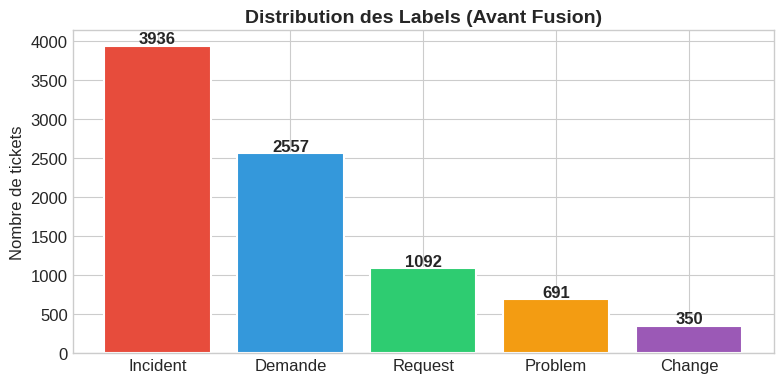

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

label_counts_raw = df_raw['label'].value_counts()
colors_raw = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

bars = ax.bar(label_counts_raw.index, label_counts_raw.values,
              color=colors_raw, edgecolor='white', linewidth=1.5)

ax.set_title("Distribution des Labels (Avant Fusion)", fontsize=14, fontweight='bold')
ax.set_ylabel("Nombre de tickets")

for bar, val in zip(bars, label_counts_raw.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

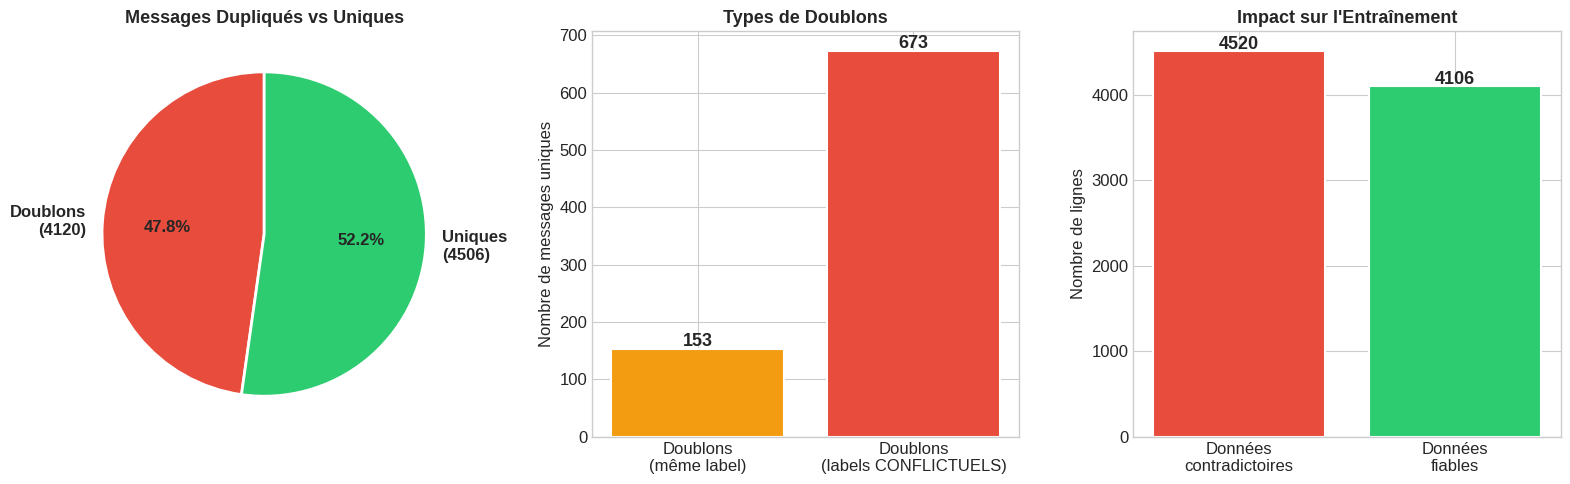

EXEMPLES DE DOUBLONS CONFLICTUELS :

📌 Message : "Bes0in d'un n0uveau clavier 0u s0uris...."
   Labels attribués : ['Demande', 'Incident']

📌 Message : "Bes0in d'un n0uveau clavier 0u s0uris. Merci...."
   Labels attribués : ['Incident', 'Demande', 'Incident', 'Demande', 'Demande']

📌 Message : "Bes0in d'un n0uveau clavier 0u s0uris. Urgent...."
   Labels attribués : ['Incident', 'Demande', 'Demande', 'Incident', 'Incident', 'Incident']

📌 Message : "Bes0in d'un n0uveu clvier 0u s0uris. ASAP...."
   Labels attribués : ['Demande', 'Incident', 'Incident', 'Incident']

📌 Message : "Bes0in d'un n0uveu clvier 0u s0uris. SVP...."
   Labels attribués : ['Demande', 'Incident']


In [ ]:
df_work = df_raw.copy()
df_work['label'] = df_work['label'].replace({'Request': 'Demande', 'Change': 'Demande', 'Problem': 'Incident'})

# Trouver les doublons
duplicates = df_work[df_work.duplicated(subset=['message'], keep=False)]
unique_messages = df_work.drop_duplicates(subset=['message'], keep='first')

# Doublons avec labels CONFLICTUELS
conflict_groups = df_work.groupby('message')['label'].nunique()
conflicting_messages = conflict_groups[conflict_groups > 1]

# --- Visualisation ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Graphe 1 : Proportion doublons vs uniques
sizes = [len(df_work) - len(unique_messages), len(unique_messages)]
labels_pie = [f'Doublons\n({sizes[0]})', f'Uniques\n({sizes[1]})']
colors_pie = ['#e74c3c', '#2ecc71']
axes[0].pie(sizes, labels=labels_pie, colors=colors_pie, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title("Messages Dupliqués vs Uniques", fontsize=13, fontweight='bold')

# Graphe 2 : Doublons totaux vs conflictuels
dup_categories = ['Doublons\n(même label)', 'Doublons\n(labels CONFLICTUELS)']
dup_counts_total = duplicates.groupby('message')['label'].nunique()
same_label = (dup_counts_total == 1).sum()
diff_label = (dup_counts_total > 1).sum()
bars = axes[1].bar(dup_categories, [same_label, diff_label],
                   color=['#f39c12', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[1].set_title("Types de Doublons", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Nombre de messages uniques")
for bar, val in zip(bars, [same_label, diff_label]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val),
                 ha='center', fontweight='bold', fontsize=13)

# Graphe 3 : Impact sur l'entraînement
impact = ['Données\ncontradictoires', 'Données\nfiables']
impact_counts = [
    df_work[df_work['message'].isin(conflicting_messages.index)].shape[0],
    len(df_work) - df_work[df_work['message'].isin(conflicting_messages.index)].shape[0]
]
bars2 = axes[2].bar(impact, impact_counts, color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5)
axes[2].set_title("Impact sur l'Entraînement", fontsize=13, fontweight='bold')
axes[2].set_ylabel("Nombre de lignes")
for bar, val in zip(bars2, impact_counts):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(val),
                 ha='center', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig("probleme1_doublons.png", dpi=150, bbox_inches='tight')
plt.show()

# Exemples de conflits
print("=" * 60)
print("EXEMPLES DE DOUBLONS CONFLICTUELS :")
print("=" * 60)
for msg in conflicting_messages.index[:5]:
    sub = df_work[df_work['message'] == msg][['message', 'label']]
    print(f"\n📌 Message : \"{msg[:80]}...\"")
    print(f"   Labels attribués : {sub['label'].tolist()}")


/tmp/ipykernel_3836/3035466353.py:23: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3836/3035466353.py:23: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3836/3035466353.py:24: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.savefig("probleme2_sujets.png", dpi=150, bbox_inches='tight')
/tmp/ipykernel_3836/3035466353.py:24: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.savefig("probleme2_sujets.png", dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missin

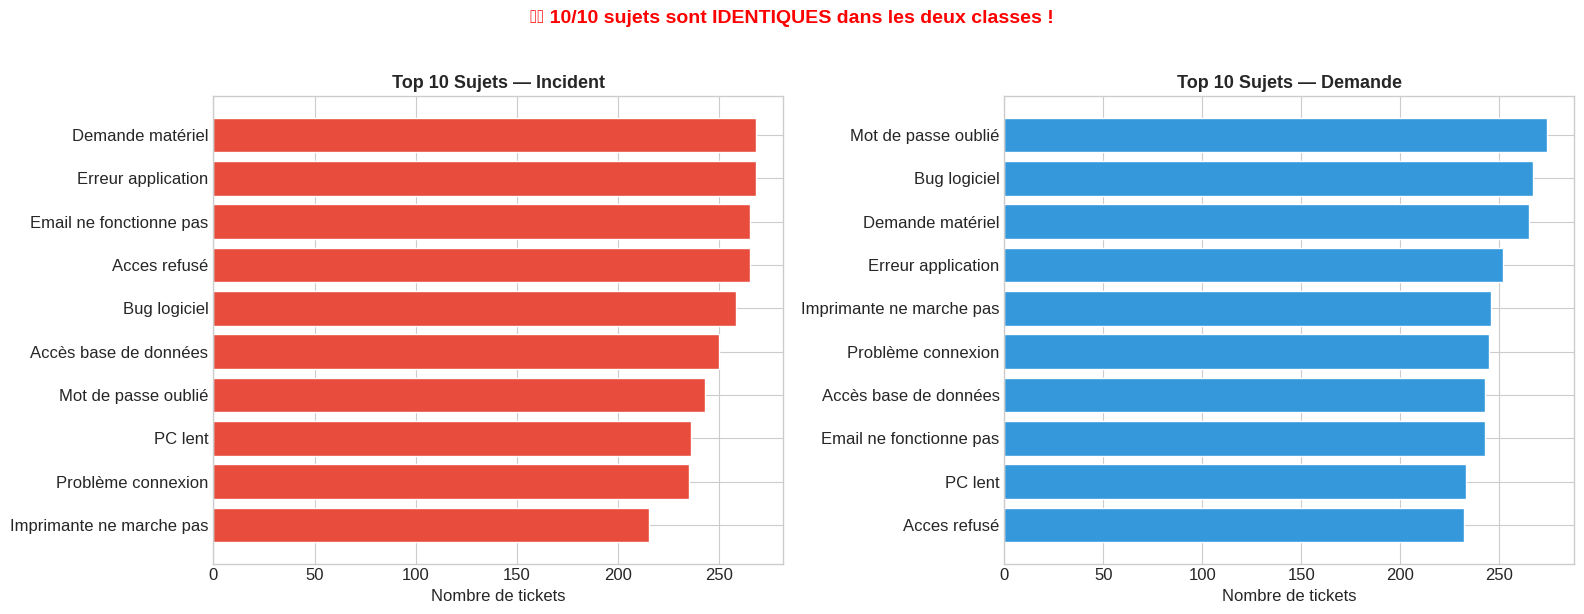


🔴 Sujets communs aux deux classes (10/10) :
   • Mot de passe oublié            →  Incident: 243  |  Demande: 274
   • Erreur application             →  Incident: 268  |  Demande: 252
   • Demande matériel               →  Incident: 268  |  Demande: 265
   • Accès base de données          →  Incident: 250  |  Demande: 243
   • Email ne fonctionne pas        →  Incident: 265  |  Demande: 243
   • Acces refusé                   →  Incident: 265  |  Demande: 232
   • PC lent                        →  Incident: 236  |  Demande: 233
   • Bug logiciel                   →  Incident: 258  |  Demande: 267
   • Imprimante ne marche pas       →  Incident: 215  |  Demande: 246
   • Problème connexion             →  Incident: 235  |  Demande: 245


In [ ]:
top_sujets_incident = df_work[df_work['label']=='Incident']['sujet'].value_counts().head(10)
top_sujets_demande = df_work[df_work['label']=='Demande']['sujet'].value_counts().head(10)

# Trouver les sujets communs aux deux classes
common_sujets = set(top_sujets_incident.index) & set(top_sujets_demande.index)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphe Incident
colors_inc = ['#e74c3c' if s in common_sujets else '#95a5a6' for s in top_sujets_incident.index]
axes[0].barh(top_sujets_incident.index[::-1], top_sujets_incident.values[::-1], color=colors_inc[::-1], edgecolor='white')
axes[0].set_title("Top 10 Sujets — Incident", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Nombre de tickets")

# Graphe Demande
colors_dem = ['#3498db' if s in common_sujets else '#95a5a6' for s in top_sujets_demande.index]
axes[1].barh(top_sujets_demande.index[::-1], top_sujets_demande.values[::-1], color=colors_dem[::-1], edgecolor='white')
axes[1].set_title("Top 10 Sujets — Demande", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Nombre de tickets")

plt.suptitle(f"⚠️ {len(common_sujets)}/{10} sujets sont IDENTIQUES dans les deux classes !",
             fontsize=14, fontweight='bold', color='red', y=1.02)
plt.tight_layout()
plt.savefig("probleme2_sujets.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🔴 Sujets communs aux deux classes ({len(common_sujets)}/10) :")
for s in common_sujets:
    inc_count = top_sujets_incident.get(s, 0)
    dem_count = top_sujets_demande.get(s, 0)
    print(f"   • {s:30s} →  Incident: {inc_count}  |  Demande: {dem_count}")


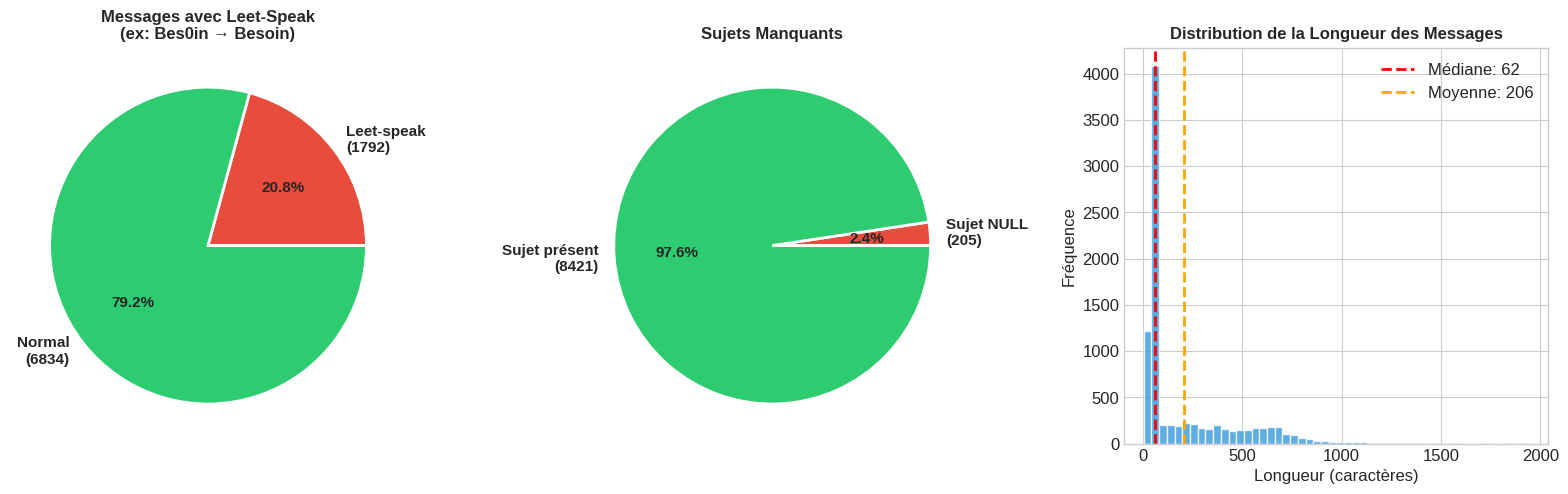

In [ ]:
leet_pattern = re.compile(r'[a-zàâçéèêëîïôûùüÿ][0-9][a-zàâçéèêëîïôûùüÿ]', re.IGNORECASE)
df_work['has_leet'] = df_work['message'].apply(lambda x: bool(leet_pattern.search(str(x))))
leet_messages = df_work[df_work['has_leet']]

# Statistiques de bruit
msg_lengths = df_work['message'].str.len()
null_sujets = df_work['sujet'].isnull().sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Graphe 1 : Messages avec leet-speak
leet_counts = [len(leet_messages), len(df_work) - len(leet_messages)]
axes[0].pie(leet_counts,
            labels=[f'Leet-speak\n({leet_counts[0]})', f'Normal\n({leet_counts[1]})'],
            colors=['#e74c3c', '#2ecc71'], autopct='%1.1f%%',
            textprops={'fontsize': 11, 'fontweight': 'bold'},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title("Messages avec Leet-Speak\n(ex: Bes0in → Besoin)", fontsize=12, fontweight='bold')

# Graphe 2 : Sujets manquants
null_counts = [null_sujets, len(df_work) - null_sujets]
axes[1].pie(null_counts,
            labels=[f'Sujet NULL\n({null_sujets})', f'Sujet présent\n({null_counts[1]})'],
            colors=['#e74c3c', '#2ecc71'], autopct='%1.1f%%',
            textprops={'fontsize': 11, 'fontweight': 'bold'},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title("Sujets Manquants", fontsize=12, fontweight='bold')

# Graphe 3 : Distribution de la longueur des messages
axes[2].hist(msg_lengths, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[2].axvline(msg_lengths.median(), color='red', linestyle='--', linewidth=2, label=f'Médiane: {msg_lengths.median():.0f}')
axes[2].axvline(msg_lengths.mean(), color='orange', linestyle='--', linewidth=2, label=f'Moyenne: {msg_lengths.mean():.0f}')
axes[2].set_title("Distribution de la Longueur des Messages", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Longueur (caractères)")
axes[2].set_ylabel("Fréquence")
axes[2].legend()

plt.tight_layout()
plt.savefig("probleme3_bruit.png", dpi=150, bbox_inches='tight')
plt.show()



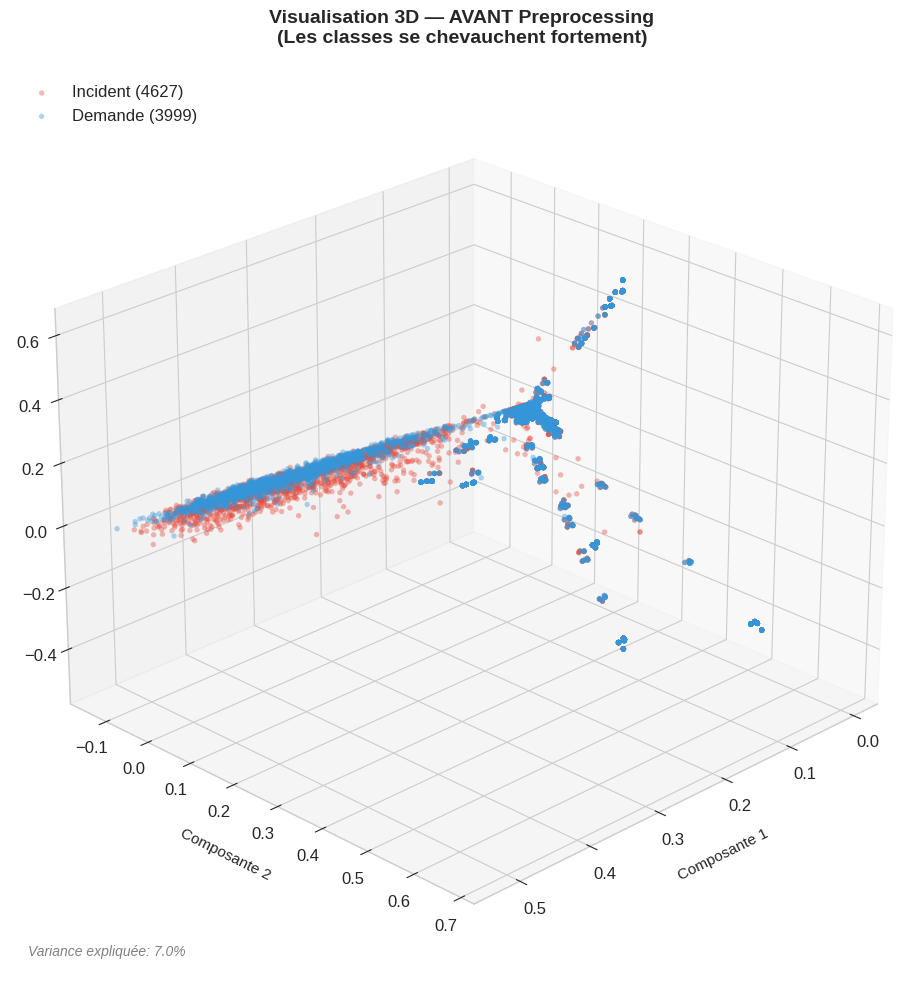

📊 Données brutes : 8626 points
   Variance expliquée par 3 composantes : 7.0%
   ⚠️ Les deux classes sont très mélangées → le modèle ne peut pas bien les séparer


In [ ]:
df_before = df_work.copy()
df_before['message_lower'] = df_before['message'].fillna("").str.lower()

# TF-IDF simple sur les messages bruts
tfidf_before = TfidfVectorizer(max_features=5000, ngram_range=(1,2), max_df=0.95, min_df=2)
X_before = tfidf_before.fit_transform(df_before['message_lower'])

# Réduction à 3 dimensions avec TruncatedSVD (PCA pour matrices sparses)
svd_before = TruncatedSVD(n_components=3, random_state=42)
X_3d_before = svd_before.fit_transform(X_before)

# --- Plot 3D ---
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Séparer par classe
mask_incident = df_before['label'] == 'Incident'
mask_demande = df_before['label'] == 'Demande'

ax.scatter(X_3d_before[mask_incident, 0], X_3d_before[mask_incident, 1], X_3d_before[mask_incident, 2],
           c='#e74c3c', alpha=0.4, s=15, label=f'Incident ({mask_incident.sum()})', edgecolors='none')
ax.scatter(X_3d_before[mask_demande, 0], X_3d_before[mask_demande, 1], X_3d_before[mask_demande, 2],
           c='#3498db', alpha=0.4, s=15, label=f'Demande ({mask_demande.sum()})', edgecolors='none')

ax.set_xlabel('Composante 1', fontsize=11, labelpad=10)
ax.set_ylabel('Composante 2', fontsize=11, labelpad=10)
ax.set_zlabel('Composante 3', fontsize=11, labelpad=10)
ax.set_title('Visualisation 3D — AVANT Preprocessing\n(Les classes se chevauchent fortement)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper left')
ax.view_init(elev=25, azim=45)

# Ajouter la variance expliquée
total_var = svd_before.explained_variance_ratio_.sum() * 100
ax.text2D(0.02, 0.02, f'Variance expliquée: {total_var:.1f}%', transform=ax.transAxes,
          fontsize=10, style='italic', color='gray')

plt.tight_layout()
plt.savefig("3d_avant_preprocessing.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"📊 Données brutes : {len(df_before)} points")
print(f"   Variance expliquée par 3 composantes : {total_var:.1f}%")
print(f"   ⚠️ Les deux classes sont très mélangées → le modèle ne peut pas bien les séparer")


In [ ]:
df_plot = pd.DataFrame({
    'x': X_3d_before[:, 0],
    'y': X_3d_before[:, 1],
    'z': X_3d_before[:, 2],
    'label': df_before['label'].values
})


centroids = df_plot.groupby('label')[['x','y','z']].mean().reset_index()

# Graph interactive
fig = px.scatter_3d(
    df_plot,
    x='x', y='y', z='z',
    color='label',
    opacity=0.6,
    title="Visualisation 3D Interactive — AVANT Preprocessing",
)

fig.update_traces(marker=dict(size=4))

fig.add_scatter3d(
    x=centroids['x'],
    y=centroids['y'],
    z=centroids['z'],
    mode='markers+text',
    marker=dict(size=12, color='black'),
    text=centroids['label'],
    textposition="top center",
    name="Centroid"
)

fig.show()

In [ ]:
def clean_text(t):
    if pd.isna(t):
        return ""
    t = str(t).lower()
    # Normalize leet-speak
    t = t.replace('0', 'o').replace('1', 'i').replace('3', 'e').replace('4', 'a')
    # Remove non-alpha characters (keep French accents)
    t = re.sub(r'[^a-zàâçéèêëîïôûùüÿñæœ\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

In [ ]:
df_raw['label'] = df_raw['label'].replace({
    'Request': 'Demande',
    'Change': 'Demande',
    'Problem': 'Incident'
})

In [ ]:
# Application initiale du nettoyage sur df_raw
df_raw['message_clean'] = df_raw['message'].apply(clean_text)
df_raw['sujet_clean'] = df_raw['sujet'].apply(clean_text)

In [ ]:
label_votes = df_raw.groupby('message_clean')['label'].agg(lambda x: x.value_counts().index[0])
label_votes = label_votes.reset_index()
label_votes.columns = ['message_clean', 'label_resolved']

before_count = len(df_raw)
# Deduplicate: keep first occurrence per unique message, then apply resolved label
df_raw = df_raw.drop_duplicates(subset=['message_clean'], keep='first').copy()
df_raw = df_raw.merge(label_votes, on='message_clean', how='left')
df_raw['label'] = df_raw['label_resolved']
df_raw = df_raw.drop(columns=['label_resolved'])

In [ ]:
stop_words_iso = set(stopwordsiso.stopwords("fr"))

stp_word1 = pd.read_csv("frenc1h.txt", header=None)
stp_word1 = set(stp_word1[0].str.strip())
stp_word2 = pd.read_csv("french2.txt", header=None)
stp_word2 = set(stp_word2[0].str.strip())

stop_words_fr = set(nltk.corpus.stopwords.words('french'))

custom_stop_words = {
    'plus', 'jour', 'etre', 'faire', 'avoir', 'merci', 'svp', 'bonjour',
    'voici', 'voilà', 'cordialement', 'salutations', 'etc', 'ici', 'bien', 'tout', 'comme', 'comment', 'pourquoi'
}

global_stop_words = text.ENGLISH_STOP_WORDS.union(stop_words_fr).union(custom_stop_words).union(stp_word1).union(stp_word2).union(stop_words_iso)

In [ ]:
INCIDENT_KEYWORDS = [
    "erreur", "panne", "bug", "bloqué", "bloque", "crash", "lent",
    "impossible", "ne fonctionne", "ne marche", "ne s'ouvre",
    "ne répond", "ne démarre", "écran noir", "écran bleu",
    "plantage", "dysfonctionnement", "défaillance", "coupé",
    "interrompu", "perdu", "corrompu", "endommagé", "détecté",
    "vulnérabilité", "violation", "incident", "problème",
    "signaler", "urgence", "urgent", "critique", "sévère",
    "tombé", "tombe", "redémarre", "freeze", "gel", "gelé",
    "ralenti", "surchauffe", "bruit", "casse", "cassé",
    "infecté", "virus", "malware", "attaque", "fuite",
    "échec", "échoué", "refusé", "timeout", "expir",
    "inaccessible", "indisponible", "hors service",
    "ne charge pas", "ne se connecte", "déconnecté",
    "incohérence", "retard", "irrégulier",
]

DEMANDE_KEYWORDS = [
    "demande", "besoin", "installer", "installation", "configurer",
    "configuration", "créer", "création", "ajouter", "ajout",
    "nouveau", "nouvelle", "accès", "autorisation", "permission",
    "licence", "abonnement", "mise à jour", "mise à niveau",
    "upgrade", "migration", "déployer", "déploiement",
    "commander", "commande", "fournir", "obtenir",
    "renseigne", "information", "renseignement",
    "souhaite", "souhaiterais", "voudrais", "voudrait",
    "pourriez", "pouvez", "possible", "envisager",
    "recommandation", "suggestion", "conseil",
    "optimiser", "améliorer", "amélioration", "extension",
    "intégration", "intégrer", "automatiser",
    "former", "formation", "tutoriel",
    "planifier", "prévoir", "budget",
    "proposer", "proposition", "devis",
    "remplacer", "remplacement", "changer", "changement",
    "ajuster", "adapter", "personnaliser",
]

In [ ]:
def extract_keyword_features(texts):
    """Extract keyword-based features for each text."""
    features = []
    for t in texts:
        t_lower = t.lower()
        incident_count = sum(1 for kw in INCIDENT_KEYWORDS if kw in t_lower)
        demande_count = sum(1 for kw in DEMANDE_KEYWORDS if kw in t_lower)

        # Ratio features
        total = incident_count + demande_count + 1  # +1 to avoid div by zero
        incident_ratio = incident_count / total
        demande_ratio = demande_count / total

        # Negation patterns (strong incident indicator)
        negation = len(re.findall(r'ne\s+\w+\s+pas|impossible|aucun|pas\s+de|plus\s+de', t_lower))

        # Question marks / politeness (demande indicator)
        question = t.count('?') + len(re.findall(r'pourriez|pouvez|serait|possible|svp|merci', t_lower))

        # Urgency markers (incident indicator)
        urgency = len(re.findall(r'urgent|critique|immédiat|asap|rapidement|toute urgence|priorit', t_lower))

        # Text length (longer messages tend to be incidents with details)
        length = len(t)

        features.append([
            incident_count, demande_count,
            incident_ratio, demande_ratio,
            negation, question, urgency,
            length,
        ])

    return np.array(features)

In [ ]:
df_raw['text_for_tfidf'] = df_raw['message_clean']

# But combine for keyword extraction (more context = better)
df_raw['text_for_keywords'] = df_raw['message_clean'] + " " + df_raw['sujet_clean']

X_tfidf_text = df_raw['text_for_tfidf']
X_keyword_text = df_raw['text_for_keywords']
y = df_raw['label']

In [ ]:

df_clean = df_raw.copy()

print(f"✅ Nettoyage terminé. Lignes restantes : {len(df_clean)}")

✅ Nettoyage terminé. Lignes restantes : 4071


In [ ]:

# On splitte les index de df_clean (la version sans doublons et sans conflits)
X_train_idx, X_test_idx, y_train, y_test = train_test_split(
    df_clean.index, df_clean['label'], test_size=0.2, random_state=42, stratify=df_clean['label']
)

# Préparation des textes pour TF-IDF (en utilisant df_clean)
X_train_tfidf_text = df_clean.loc[X_train_idx, 'message_clean']
X_test_tfidf_text = df_clean.loc[X_test_idx, 'message_clean']

# Préparation des textes pour les mots-clés (sujet + message)
X_train_keyword_text = df_clean.loc[X_train_idx, 'sujet_clean'] + " " + df_clean.loc[X_train_idx, 'message_clean']
X_test_keyword_text = df_clean.loc[X_test_idx, 'sujet_clean'] + " " + df_clean.loc[X_test_idx, 'message_clean']

print(f"✅ Split terminé sur data nettoyée.")
print(f"Train set: {len(X_train_idx)} | Test set: {len(X_test_idx)}")


✅ Split terminé sur data nettoyée.
Train set: 3256 | Test set: 815


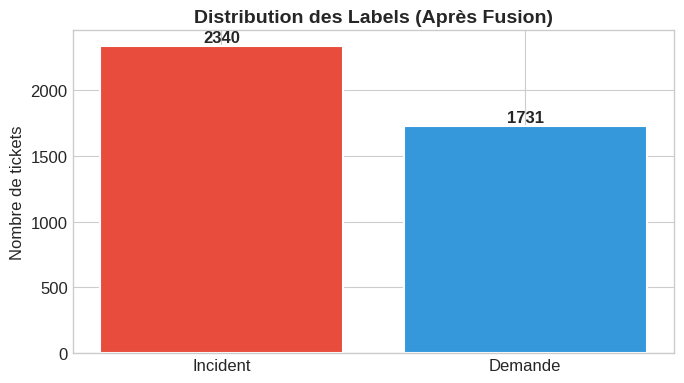


Fusion : Request/Change → Demande | Problem → Incident
Incident : 2340 tickets
Demande  : 1731 tickets


In [ ]:

df_merged = df_raw.copy()
fig, ax = plt.subplots(figsize=(7, 4))

label_counts_merged = df_merged['label'].value_counts()
colors_merged = ['#e74c3c', '#3498db']

bars = ax.bar(label_counts_merged.index, label_counts_merged.values,
              color=colors_merged, edgecolor='white', linewidth=1.5)

ax.set_title("Distribution des Labels (Après Fusion)", fontsize=14, fontweight='bold')
ax.set_ylabel("Nombre de tickets")

for bar, val in zip(bars, label_counts_merged.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nFusion : Request/Change → Demande | Problem → Incident")
print(f"Incident : {label_counts_merged['Incident']} tickets")
print(f"Demande  : {label_counts_merged['Demande']} tickets")

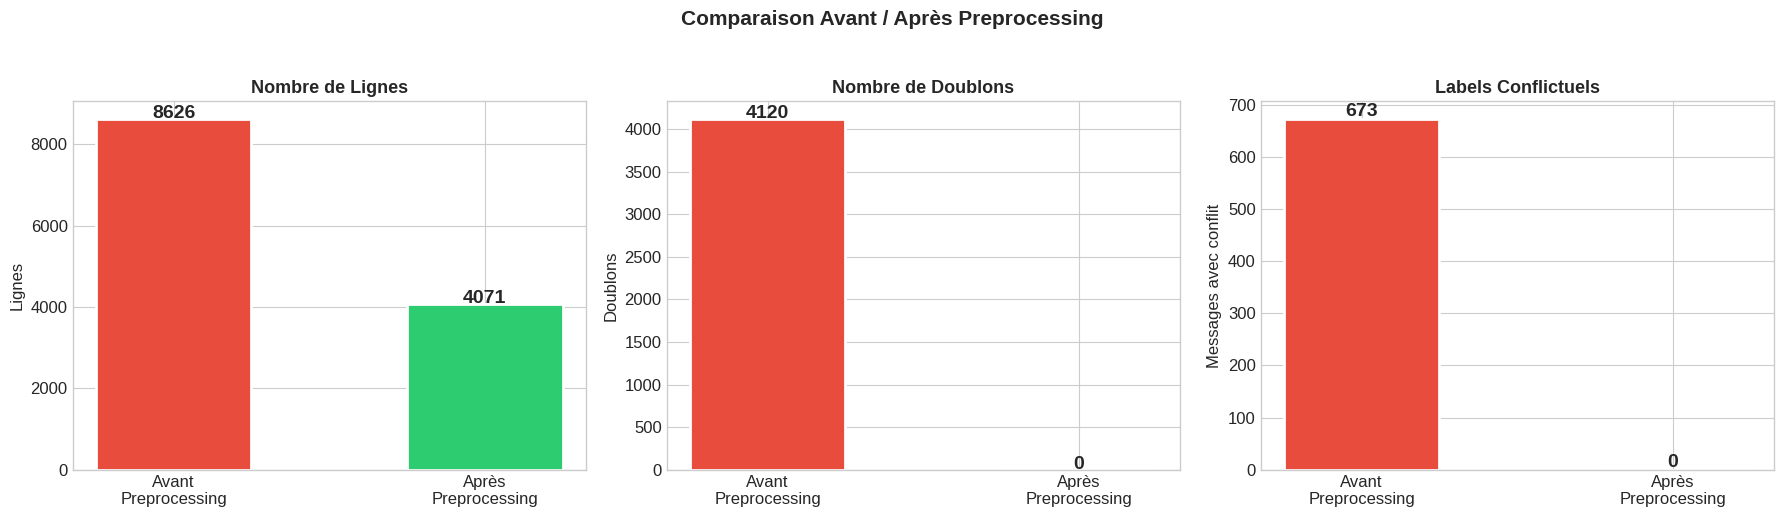

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graphe 1 : Taille du dataset
categories = ['Avant\nPreprocessing', 'Après\nPreprocessing']
sizes_comparison = [len(df_work), len(df_clean)]
colors_comp = ['#e74c3c', '#2ecc71']
bars = axes[0].bar(categories, sizes_comparison, color=colors_comp, edgecolor='white', linewidth=2, width=0.5)
axes[0].set_title("Nombre de Lignes", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Lignes")
for bar, val in zip(bars, sizes_comparison):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, str(val),
                 ha='center', fontweight='bold', fontsize=14)

# Graphe 2 : Doublons avant / après
dup_before = len(df_work) - df_work['message'].nunique()
dup_after = len(df_clean) - df_clean['message_clean'].nunique()
bars2 = axes[1].bar(categories, [dup_before, dup_after], color=colors_comp, edgecolor='white', linewidth=2, width=0.5)
axes[1].set_title("Nombre de Doublons", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Doublons")
for bar, val in zip(bars2, [dup_before, dup_after]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(val),
                 ha='center', fontweight='bold', fontsize=14)

# Graphe 3 : Conflits avant / après
conflicts_before = len(conflicting_messages)
conflict_check = df_clean.groupby('message_clean')['label'].nunique()
conflicts_after = (conflict_check > 1).sum()
bars3 = axes[2].bar(categories, [conflicts_before, conflicts_after], color=colors_comp, edgecolor='white', linewidth=2, width=0.5)
axes[2].set_title("Labels Conflictuels", fontsize=13, fontweight='bold')
axes[2].set_ylabel("Messages avec conflit")
for bar, val in zip(bars3, [conflicts_before, conflicts_after]):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val),
                 ha='center', fontweight='bold', fontsize=14)

plt.suptitle("Comparaison Avant / Après Preprocessing", fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig("comparaison_avant_apres.png", dpi=150, bbox_inches='tight')
plt.show()


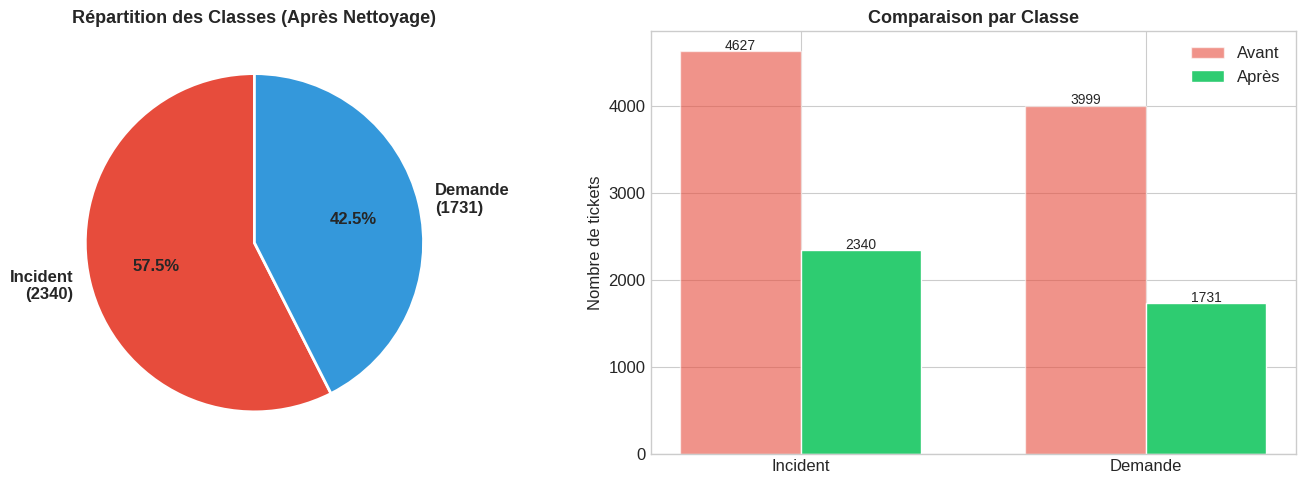

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
label_clean_counts = df_clean['label'].value_counts()
axes[0].pie(label_clean_counts.values,
            labels=[f"{l}\n({v})" for l, v in zip(label_clean_counts.index, label_clean_counts.values)],
            colors=['#e74c3c', '#3498db'], autopct='%1.1f%%',
            textprops={'fontsize': 12, 'fontweight': 'bold'},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            startangle=90)
axes[0].set_title("Répartition des Classes (Après Nettoyage)", fontsize=13, fontweight='bold')

# Bar chart comparatif
x = np.arange(2)
width = 0.35
before_vals = [df_work[df_work['label']=='Incident'].shape[0], df_work[df_work['label']=='Demande'].shape[0]]
after_vals = [df_clean[df_clean['label']=='Incident'].shape[0], df_clean[df_clean['label']=='Demande'].shape[0]]

bars1 = axes[1].bar(x - width/2, before_vals, width, label='Avant', color='#e74c3c', alpha=0.6, edgecolor='white')
bars2 = axes[1].bar(x + width/2, after_vals, width, label='Après', color='#2ecc71', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Incident', 'Demande'])
axes[1].set_title("Comparaison par Classe", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Nombre de tickets")
axes[1].legend(fontsize=12)

for bar, val in zip(bars1, before_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(val), ha='center', fontsize=10)
for bar, val in zip(bars2, after_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(val), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig("distribution_apres_nettoyage.png", dpi=150, bbox_inches='tight')
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning:

Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['quelqu'] not in stop_words.



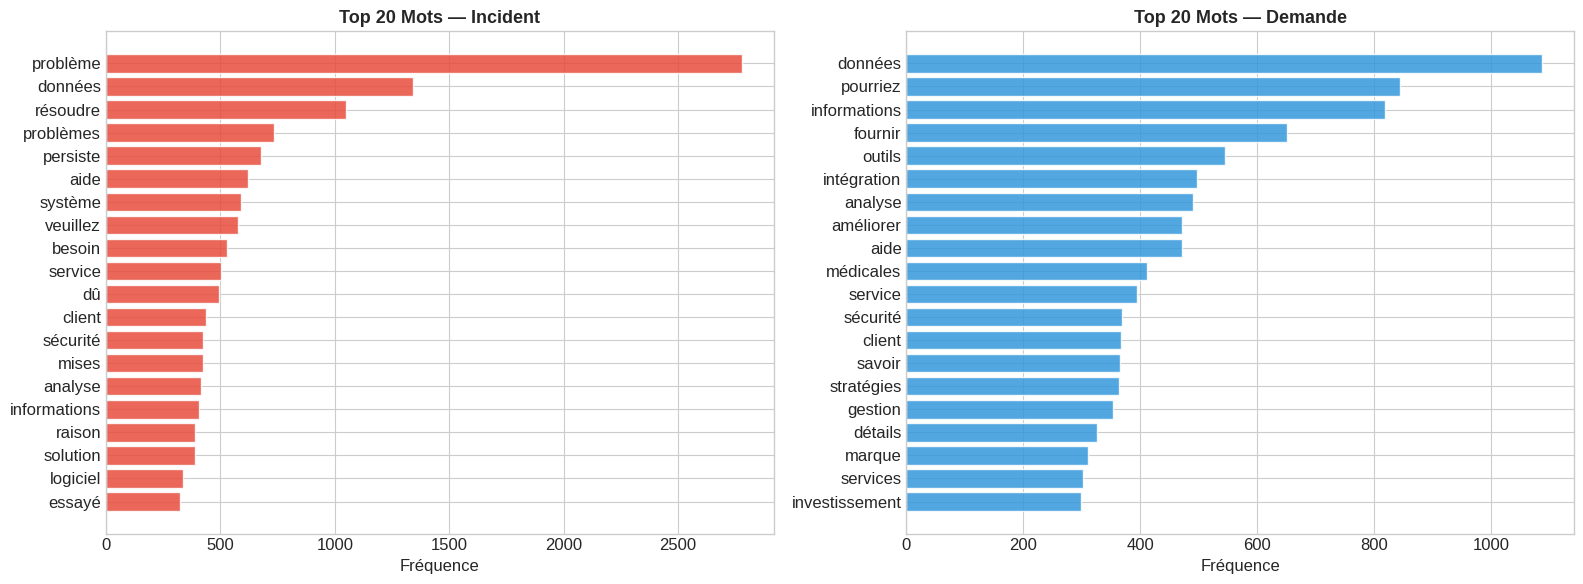

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, label in enumerate(['Incident', 'Demande']):
    subset = df_clean[df_clean['label'] == label]['message_clean']

    vec = CountVectorizer(max_features=20, stop_words=list(global_stop_words))
    X = vec.fit_transform(subset)
    word_counts = dict(zip(vec.get_feature_names_out(), X.sum(axis=0).A1))
    sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)

    words = [w[0] for w in sorted_words]
    counts = [w[1] for w in sorted_words]

    color = '#e74c3c' if label == 'Incident' else '#3498db'
    axes[idx].barh(words[::-1], counts[::-1], color=color, edgecolor='white', alpha=0.85)
    axes[idx].set_title(f"Top 20 Mots — {label}", fontsize=13, fontweight='bold')
    axes[idx].set_xlabel("Fréquence")

plt.tight_layout()
plt.savefig("mots_frequents_par_classe.png", dpi=150, bbox_inches='tight')
plt.show()


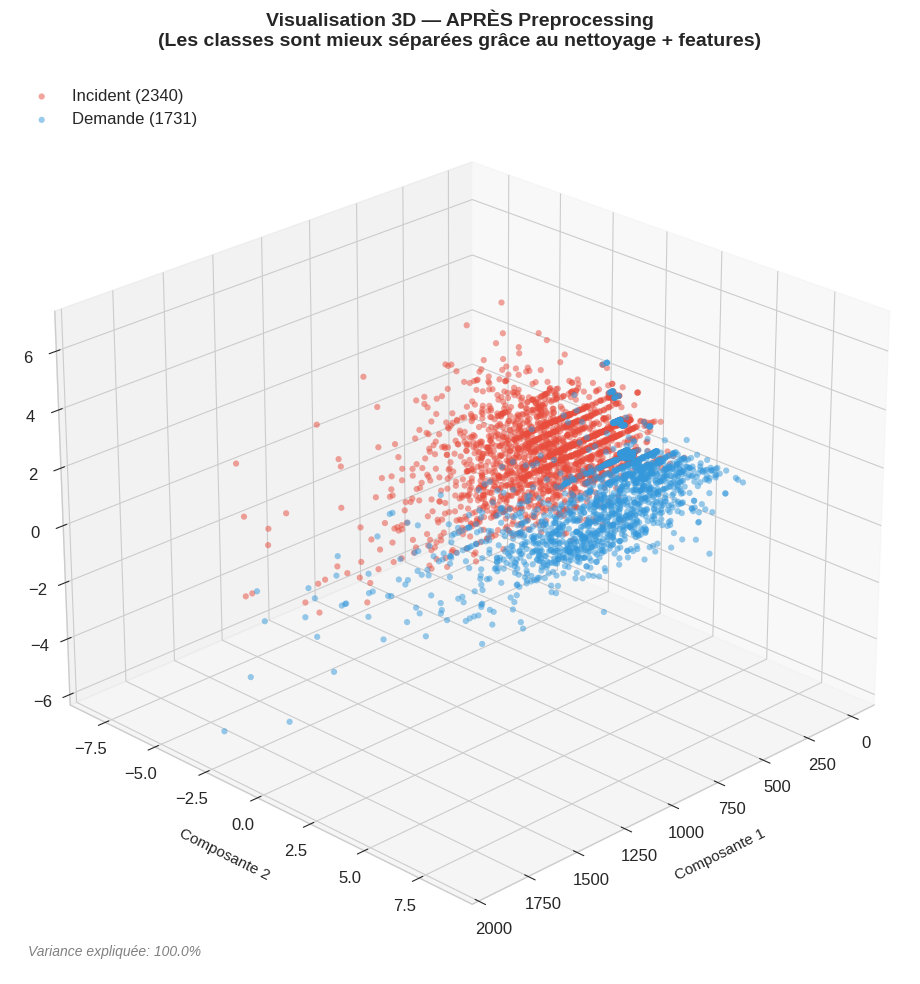

📊 Données nettoyées : 4071 points
   Variance expliquée par 3 composantes : 100.0%
   ✅ Les classes sont mieux séparées → le modèle peut mieux apprendre


In [ ]:
tfidf_word_after = TfidfVectorizer(max_features=5000, ngram_range=(1,2), max_df=0.95, min_df=2, sublinear_tf=True)
X_word_after = tfidf_word_after.fit_transform(df_clean['message_clean'])

# TF-IDF Char sur messages nettoyés
tfidf_char_after = TfidfVectorizer(max_features=3000, ngram_range=(2,5), analyzer='char_wb', max_df=0.95, min_df=2, sublinear_tf=True)
X_char_after = tfidf_char_after.fit_transform(df_clean['message_clean'])


X_kw_after = extract_keyword_features(df_clean['message_clean'].values)

# Combiner toutes les features
X_combined_after = hstack([X_word_after, X_char_after, csr_matrix(X_kw_after)])

# Réduction à 3D
svd_after = TruncatedSVD(n_components=3, random_state=42)
X_3d_after = svd_after.fit_transform(X_combined_after)

# --- Plot 3D ---
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

mask_incident = df_clean['label'] == 'Incident'
mask_demande = df_clean['label'] == 'Demande'

ax.scatter(X_3d_after[mask_incident.values, 0], X_3d_after[mask_incident.values, 1], X_3d_after[mask_incident.values, 2],
           c='#e74c3c', alpha=0.5, s=20, label=f'Incident ({mask_incident.sum()})', edgecolors='none')
ax.scatter(X_3d_after[mask_demande.values, 0], X_3d_after[mask_demande.values, 1], X_3d_after[mask_demande.values, 2],
           c='#3498db', alpha=0.5, s=20, label=f'Demande ({mask_demande.sum()})', edgecolors='none')

ax.set_xlabel('Composante 1', fontsize=11, labelpad=10)
ax.set_ylabel('Composante 2', fontsize=11, labelpad=10)
ax.set_zlabel('Composante 3', fontsize=11, labelpad=10)
ax.set_title('Visualisation 3D — APRÈS Preprocessing\n(Les classes sont mieux séparées grâce au nettoyage + features)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper left')
ax.view_init(elev=25, azim=45)

total_var_after = svd_after.explained_variance_ratio_.sum() * 100
ax.text2D(0.02, 0.02, f'Variance expliquée: {total_var_after:.1f}%', transform=ax.transAxes,
          fontsize=10, style='italic', color='gray')

plt.tight_layout()
plt.savefig("3d_apres_preprocessing.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"📊 Données nettoyées : {len(df_clean)} points")
print(f"   Variance expliquée par 3 composantes : {total_var_after:.1f}%")
print(f"   ✅ Les classes sont mieux séparées → le modèle peut mieux apprendre")


In [ ]:
df_plot_after = pd.DataFrame({
    'x': X_3d_after[:, 0],
    'y': X_3d_after[:, 1],
    'z': X_3d_after[:, 2],
    'label': df_clean['label'].values
})

centroids_after = df_plot_after.groupby('label')[['x','y','z']].mean().reset_index()

fig = px.scatter_3d(
    df_plot_after,
    x='x', y='y', z='z',
    color='label',
    opacity=0.7,
    title="Visualisation 3D Interactive — APRÈS Preprocessing (Classes mieux séparées)",
)

fig.update_traces(marker=dict(size=5))

fig.add_scatter3d(
    x=centroids_after['x'],
    y=centroids_after['y'],
    z=centroids_after['z'],
    mode='markers+text',
    marker=dict(size=12, color='black'),
    text=centroids_after['label'],
    textposition="top center",
    name="Centroid"
)

fig.show()

/tmp/ipykernel_3836/3690691432.py:31: UserWarning:

Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.

/tmp/ipykernel_3836/3690691432.py:31: UserWarning:

Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Liberation Sans.

/tmp/ipykernel_3836/3690691432.py:32: UserWarning:

Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.

/tmp/ipykernel_3836/3690691432.py:32: UserWarning:

Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Liberation Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Liberation Sans.



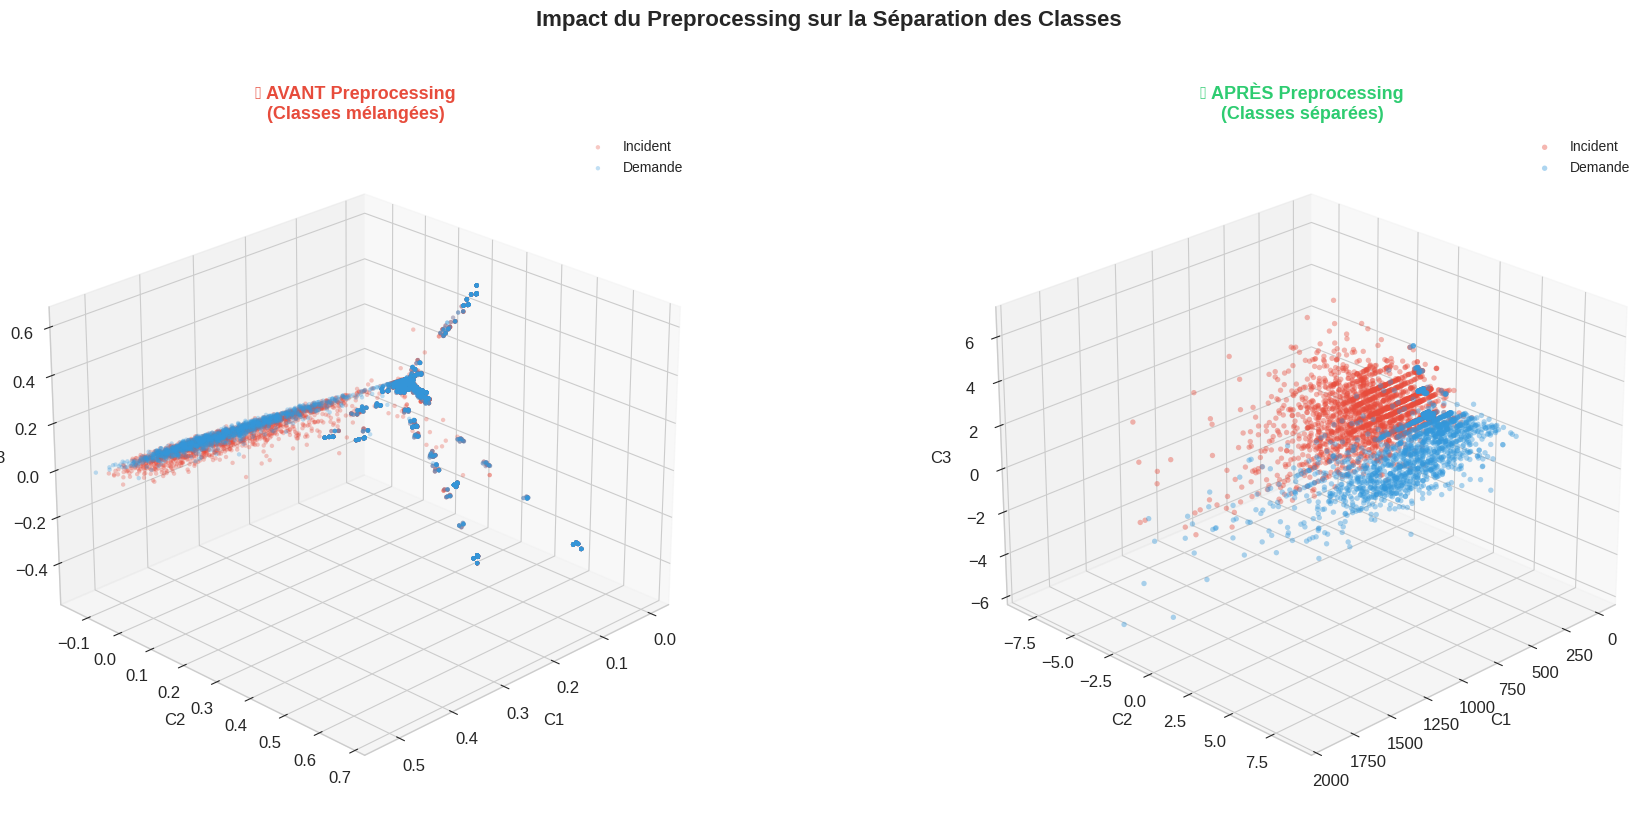

In [ ]:
fig = plt.figure(figsize=(20, 8))

# --- AVANT ---
ax1 = fig.add_subplot(121, projection='3d')
mask_inc_b = df_before['label'] == 'Incident'
mask_dem_b = df_before['label'] == 'Demande'
ax1.scatter(X_3d_before[mask_inc_b, 0], X_3d_before[mask_inc_b, 1], X_3d_before[mask_inc_b, 2],
            c='#e74c3c', alpha=0.3, s=10, label='Incident', edgecolors='none')
ax1.scatter(X_3d_before[mask_dem_b, 0], X_3d_before[mask_dem_b, 1], X_3d_before[mask_dem_b, 2],
            c='#3498db', alpha=0.3, s=10, label='Demande', edgecolors='none')
ax1.set_title('❌ AVANT Preprocessing\n(Classes mélangées)', fontsize=13, fontweight='bold', color='#e74c3c')
ax1.set_xlabel('C1'); ax1.set_ylabel('C2'); ax1.set_zlabel('C3')
ax1.legend(fontsize=10)
ax1.view_init(elev=25, azim=45)

# --- APRÈS ---
ax2 = fig.add_subplot(122, projection='3d')
mask_inc_a = df_clean['label'] == 'Incident'
mask_dem_a = df_clean['label'] == 'Demande'
ax2.scatter(X_3d_after[mask_inc_a.values, 0], X_3d_after[mask_inc_a.values, 1], X_3d_after[mask_inc_a.values, 2],
            c='#e74c3c', alpha=0.4, s=15, label='Incident', edgecolors='none')
ax2.scatter(X_3d_after[mask_dem_a.values, 0], X_3d_after[mask_dem_a.values, 1], X_3d_after[mask_dem_a.values, 2],
            c='#3498db', alpha=0.4, s=15, label='Demande', edgecolors='none')
ax2.set_title('✅ APRÈS Preprocessing\n(Classes séparées)', fontsize=13, fontweight='bold', color='#2ecc71')
ax2.set_xlabel('C1'); ax2.set_ylabel('C2'); ax2.set_zlabel('C3')
ax2.legend(fontsize=10)
ax2.view_init(elev=25, azim=45)

plt.suptitle('Impact du Preprocessing sur la Séparation des Classes',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("3d_comparaison_avant_apres.png", dpi=150, bbox_inches='tight')
plt.show()


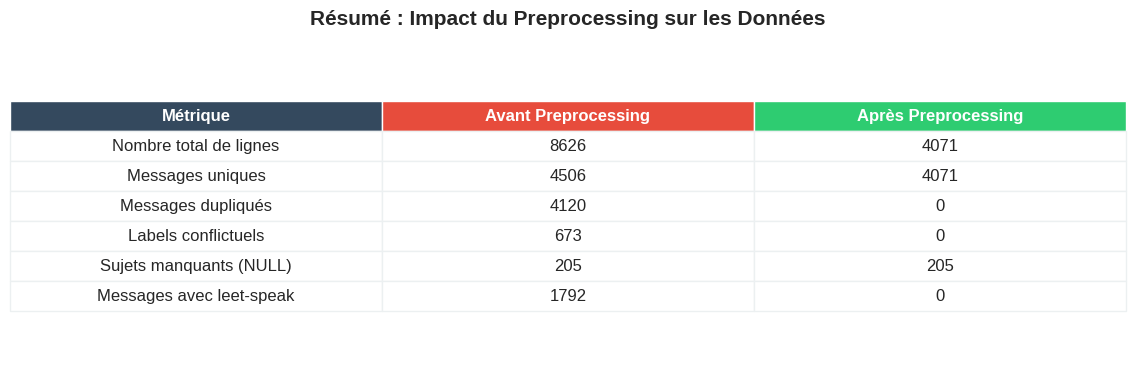


✅ Tous les problèmes ont été résolus :
   1. Doublons conflictuels → Résolus par vote majoritaire
   2. Sujets non-discriminants → Exclus du TF-IDF, remplacés par keyword features
   3. Leet-speak → Normalisé (0→o, 1→i, 3→e, 4→a)


In [ ]:
summary_data = {
    'Métrique': [
        'Nombre total de lignes',
        'Messages uniques',
        'Messages dupliqués',
        'Labels conflictuels',
        'Sujets manquants (NULL)',
        'Messages avec leet-speak',
    ],
    'Avant Preprocessing': [
        len(df_work),
        df_work['message'].nunique(),
        len(df_work) - df_work['message'].nunique(),
        len(conflicting_messages),
        df_work['sujet'].isnull().sum(),
        len(leet_messages),
    ],
    'Après Preprocessing': [
        len(df_clean),
        df_clean['message_clean'].nunique(),
        0,
        0,
        df_clean['sujet_clean'].eq('').sum(),
        0,  # Corrigés par normalisation
    ]
}

df_summary = pd.DataFrame(summary_data)

# Afficher comme un beau tableau
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')
table = ax.table(
    cellText=df_summary.values,
    colLabels=df_summary.columns,
    cellLoc='center',
    loc='center',
    colColours=['#34495e', '#e74c3c', '#2ecc71'],
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8)

# Style du header
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight='bold', color='white')
        cell.set_edgecolor('white')
    else:
        cell.set_edgecolor('#ecf0f1')

plt.title("Résumé : Impact du Preprocessing sur les Données",
          fontsize=15, fontweight='bold', pad=20)
plt.savefig("resume_preprocessing.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Tous les problèmes ont été résolus :")
print("   1. Doublons conflictuels → Résolus par vote majoritaire")
print("   2. Sujets non-discriminants → Exclus du TF-IDF, remplacés par keyword features")
print("   3. Leet-speak → Normalisé (0→o, 1→i, 3→e, 4→a)")


# **Entraînement**

In [ ]:
word_vectorizer = TfidfVectorizer(
    stop_words=list(global_stop_words),
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,       # Apply log normalization
    analyzer='word',
)

# Character-level TF-IDF (catches spelling patterns, abbreviations)
char_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(2, 5),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    analyzer='char_wb',      # Character n-grams within word boundaries
)

In [ ]:
# Transformation des données avec les vecteurs déjà définis
X_train_word = word_vectorizer.fit_transform(X_train_tfidf_text)
X_test_word = word_vectorizer.transform(X_test_tfidf_text)

X_train_char = char_vectorizer.fit_transform(X_train_tfidf_text)
X_test_char = char_vectorizer.transform(X_test_tfidf_text)

# Extraction des features de mots-clés
X_train_kw = extract_keyword_features(X_train_keyword_text.values)
X_test_kw = extract_keyword_features(X_test_keyword_text.values)

# Combinaison (csr_matrix est déjà importé au début)
X_train_combined = hstack([X_train_word, X_train_char, csr_matrix(X_train_kw)])
X_test_combined = hstack([X_test_word, X_test_char, csr_matrix(X_test_kw)])

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning:

Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['quelqu'] not in stop_words.



In [ ]:
configs = [
    {'alpha': 0.1},
    {'alpha': 0.5},
    {'alpha': 1.0},
    {'alpha': 2.0},
    {'alpha': 5.0},
]

best_acc = 0
best_model = None
best_params = None

for cfg in configs:
    model = MultinomialNB(**cfg)
    model.fit(X_train_combined, y_train)

    y_pred_val = model.predict(X_test_combined)
    acc = accuracy_score(y_test, y_pred_val)

    print(f"alpha={cfg['alpha']:<4} → acc={acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_params = cfg

print(f"\nBest config: {best_params}")

alpha=0.1  → acc=0.9239
alpha=0.5  → acc=0.9129
alpha=1.0  → acc=0.9129
alpha=2.0  → acc=0.9031
alpha=5.0  → acc=0.6896

Best config: {'alpha': 0.1}


In [ ]:
y_pred = best_model.predict(X_test_combined)

accuracy = accuracy_score(y_test, y_pred)

# Define classes_ from the unique labels in y_test
classes_ = y_test.unique()

print(f"\n{'='*60}")
print(f"  TEST ACCURACY: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"{'='*60}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=classes_)}")


  TEST ACCURACY: 0.9239 (92.39%)

Classification Report:
              precision    recall  f1-score   support

     Demande       0.95      0.87      0.91       347
    Incident       0.91      0.97      0.94       468

    accuracy                           0.92       815
   macro avg       0.93      0.92      0.92       815
weighted avg       0.93      0.92      0.92       815



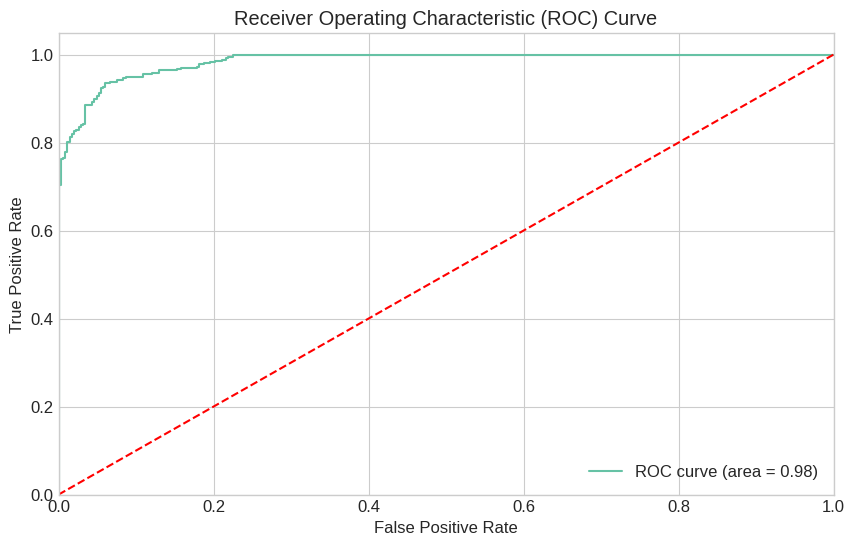

In [ ]:
y_pred_proba = best_model.predict_proba(X_test_combined)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label='Incident')
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

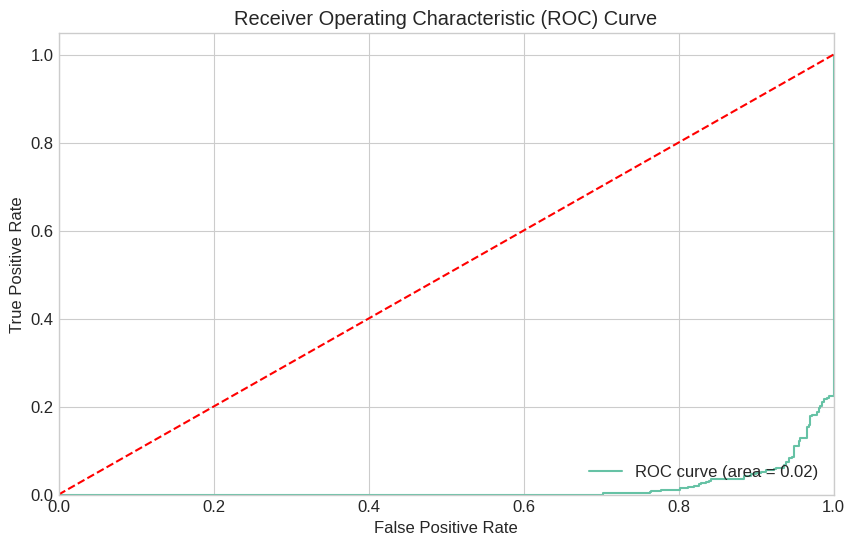

In [ ]:
y_pred_proba = best_model.predict_proba(X_test_combined)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label='Demande')
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

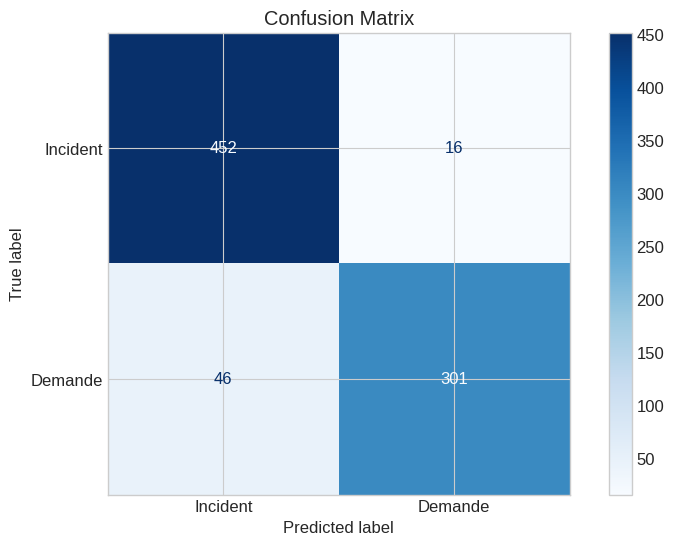

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=['Incident', 'Demande'])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Incident', 'Demande'])
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

#**Evaluation**

In [ ]:
joblib.dump(best_model, "model.pkl")
joblib.dump(word_vectorizer, "word_vectorizer.pkl")
joblib.dump(char_vectorizer, "char_vectorizer.pkl")
joblib.dump(global_stop_words, "stop_words.pkl")

['stop_words.pkl']

In [ ]:
def predict_ticket(message, sujet=""):
    """Predict the label for a new helpdesk ticket."""
    clean_msg = clean_text(message)
    clean_subj = clean_text(sujet)

    # TF-IDF features
    word_feat = word_vectorizer.transform([clean_msg])
    char_feat = char_vectorizer.transform([clean_msg])

    # Keyword features
    kw_feat = extract_keyword_features([clean_msg + " " + clean_subj])

    # Combine
    combined = hstack([word_feat, char_feat, csr_matrix(kw_feat)])

    prediction = best_model.predict(combined)[0]
    proba = best_model.predict_proba(combined)[0]
    confidence = max(proba)

    return prediction, confidence

In [ ]:
test_cases = [
    ("Impossible de me connecter au VPN", "Problème VPN"),
    ("Merci de m'ajouter un accès SAP", "Accès SAP"),
    ("Mon ordinateur est très lent", "PC lent"),
    ("Installer Office sur mon poste", "Installation Office"),
    ("Erreur au lancement du CRM", "Erreur CRM"),
    ("Créer un compte pour nouveau collaborateur", "Nouveau compte"),
    ("Notre plateforme s'est bloquée et ne répond plus", "Plateforme bloquée"),
    ("Demande de licence pour Adobe Photoshop", "Licence logiciel"),
]

for msg, subj in test_cases:
    pred_numerical, conf = predict_ticket(msg, subj)
    pred_label = pred_numerical
    print(f"  [{pred_label:>8s}] ({conf:.0%}) | {msg}")

  [Incident] (100%) | Impossible de me connecter au VPN
  [ Demande] (100%) | Merci de m'ajouter un accès SAP
  [Incident] (100%) | Mon ordinateur est très lent
  [ Demande] (98%) | Installer Office sur mon poste
  [Incident] (100%) | Erreur au lancement du CRM
  [ Demande] (100%) | Créer un compte pour nouveau collaborateur
  [Incident] (100%) | Notre plateforme s'est bloquée et ne répond plus
  [ Demande] (100%) | Demande de licence pour Adobe Photoshop
